In [32]:

import numpy as np 
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns


pd.set_option('display.max_columns', None)
pd.set_option('display.max_rows', None)


DATA_PATH = '../data/raw/air_quality_readings.csv'




In [ ]:
df = pd.read_csv(DATA_PATH)



df['timestamp'] = pd.to_datetime(df['timestamp'], errors='coerce')

In [8]:
df.head()

,reading_id,timestamp,year,month,hour,day_of_week,is_weekend,is_rush_hour,season,station_id,station_type,elevation_m,near_highway,near_industry,temp_c,humidity_pct,wind_speed_ms,wind_dir_deg,pressure_hpa,precipitation_mm,visibility_km,temp_inversion,pm25,pm10,no2,o3,so2,co,benzene,aqi,label_respiratory_risk,label_cardiovascular_risk,label_vulnerable_alert,label_outdoor_warning,label_industrial_event
0,RDG0003315,2021-12-24 18:00:00,2021,12,18,4,0,1,Winter,STN_URBAN_01,Urban,100.4,1,0,11.9,60.4,0.5,NaN,1016.5,1.0,14.7,0,58.3,92.0,61.9,33.2,0.7,6.01,3.24,152,1,1,1,1,0
1,RDG0009080,2023-09-19 21:00:00,2023,9,21,1,0,0,Fall,STN_SUBURB_01,Suburban,61.9,0,0,18.4,45.4,12.4,246.1,1017.4,0.0,6.2,0,8.5,16.2,63.6,8.9,13.2,0.59,5.00,35,0,0,0,0,0
2,RDG0005620,2022-08-28 11:00:00,2022,8,11,6,1,0,Summer,STN_SUBURB_01,Suburban,27.1,0,0,26.7,52.9,2.9,239.5,1010.6,0.0,4.3,0,13.2,23.0,16.5,74.8,3.3,1.61,2.55,53,0,0,1,0,0
3,RDG0009213,2023-10-05 06:00:00,2023,10,6,3,0,0,Fall,STN_URBAN_02,Urban,96.1,0,0,18.2,43.4,1.9,345.0,1018.5,0.0,12.4,0,20.1,41.5,58.1,17.0,22.5,1.50,NaN,68,0,0,1,0,0
4,RDG0009206,2023-10-04 05:00:00,2023,10,5,2,0,0,Fall,STN_INDUSTRIAL_01,Industrial,11.8,1,1,9.4,43.0,17.5,24.7,1007.1,10.0,3.6,0,25.5,48.2,66.4,30.8,33.9,3.31,6.20,79,0,0,1,0,1


In [9]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 10028 entries, 0 to 10027
Data columns (total 35 columns):
 #   Column                     Non-Null Count  Dtype         
---  ------                     --------------  -----         
 0   reading_id                 10028 non-null  str           
 1   timestamp                  10028 non-null  datetime64[us]
 2   year                       10028 non-null  int64         
 3   month                      10028 non-null  int64         
 4   hour                       10028 non-null  int64         
 5   day_of_week                10028 non-null  int64         
 6   is_weekend                 10028 non-null  int64         
 7   is_rush_hour               10028 non-null  int64         
 8   season                     10028 non-null  str           
 9   station_id                 10028 non-null  str           
 10  station_type               10028 non-null  str           
 11  elevation_m                10028 non-null  float64       
 12  near_highway   

In [11]:
missing_cols = ['benzene', 'visibility_km', 'pressure_hpa', 'wind_dir_deg']

In [12]:
df.describe()

,timestamp,year,month,hour,day_of_week,is_weekend,is_rush_hour,elevation_m,near_highway,near_industry,temp_c,humidity_pct,wind_speed_ms,wind_dir_deg,pressure_hpa,precipitation_mm,visibility_km,temp_inversion,pm25,pm10,no2,o3,so2,co,benzene,aqi,label_respiratory_risk,label_cardiovascular_risk,label_vulnerable_alert,label_outdoor_warning,label_industrial_event
count,10028,10028.000000,10028.000000,10028.000000,10028.000000,10028.000000,10028.000000,10028.000000,10028.000000,10028.000000,10028.000000,10028.000000,10028.000000,9525.000000,9728.000000,10028.000000,9427.000000,10028.000000,10028.000000,10028.000000,10028.000000,10028.000000,10028.000000,10028.000000,9226.000000,10028.000000,10028.000000,10028.000000,10028.000000,10028.000000,10028.000000
mean,2022-06-25 19:57:30.299162,2021.984942,6.484344,11.395193,3.003690,0.285401,0.282708,108.544675,0.321500,0.124850,14.351316,61.729148,3.541444,180.228136,1013.062192,0.728560,8.793826,0.025329,28.649132,51.818538,51.114998,35.467441,15.154767,3.467648,4.965834,78.807040,0.285102,0.180893,0.733347,0.312026,0.354507
min,2021-01-01 00:00:00,2021.000000,1.000000,0.000000,0.000000,0.000000,0.000000,5.000000,0.000000,0.000000,-19.800000,10.000000,0.000000,0.000000,984.500000,0.000000,0.800000,0.000000,1.000000,2.000000,1.800000,1.000000,0.500000,0.140000,0.130000,4.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,2021-09-27 22:45:00,2021.000000,3.000000,5.000000,1.000000,0.000000,0.000000,32.575000,0.000000,0.000000,7.200000,48.600000,1.000000,90.900000,1007.600000,0.000000,5.000000,0.000000,11.200000,19.800000,23.300000,16.700000,4.600000,1.680000,1.800000,47.000000,0.000000,0.000000,0.000000,0.000000,0.000000
50%,2022-06-24 02:30:00,2022.000000,6.000000,11.000000,3.000000,0.000000,0.000000,64.300000,0.000000,0.000000,14.000000,62.300000,2.400000,179.000000,1012.900000,0.000000,7.400000,0.000000,21.200000,38.100000,41.800000,28.550000,9.500000,2.750000,3.370000,70.000000,0.000000,0.000000,1.000000,0.000000,0.000000
75%,2023-03-21 08:45:00,2023.000000,9.000000,18.000000,5.000000,1.000000,1.000000,104.600000,1.000000,0.000000,22.200000,75.400000,4.900000,269.900000,1018.500000,0.000000,11.000000,0.000000,37.025000,67.200000,67.500000,46.100000,19.925000,4.410000,6.450000,105.000000,1.000000,0.000000,1.000000,1.000000,1.000000
max,2023-12-31 16:00:00,2023.000000,12.000000,23.000000,6.000000,1.000000,1.000000,599.900000,1.000000,1.000000,44.300000,100.000000,25.000000,360.000000,1042.700000,20.000000,30.000000,1.000000,350.000000,534.800000,400.000000,318.500000,309.500000,30.000000,50.000000,380.000000,1.000000,1.000000,1.000000,1.000000,1.000000
std,NaN,0.812459,3.443376,6.986594,2.007785,0.451628,0.450338,132.329210,0.467075,0.330566,10.428795,18.645827,3.539496,103.916288,8.052186,2.624266,5.427843,0.157130,26.735397,49.597312,38.800270,28.061973,16.772650,2.721997,4.970925,46.475989,0.451485,0.384949,0.442232,0.463344,0.478388


In [13]:
print(df.columns.tolist())

['reading_id', 'timestamp', 'year', 'month', 'hour', 'day_of_week', 'is_weekend', 'is_rush_hour', 'season', 'station_id', 'station_type', 'elevation_m', 'near_highway', 'near_industry', 'temp_c', 'humidity_pct', 'wind_speed_ms', 'wind_dir_deg', 'pressure_hpa', 'precipitation_mm', 'visibility_km', 'temp_inversion', 'pm25', 'pm10', 'no2', 'o3', 'so2', 'co', 'benzene', 'aqi', 'label_respiratory_risk', 'label_cardiovascular_risk', 'label_vulnerable_alert', 'label_outdoor_warning', 'label_industrial_event']


In [19]:
label_cols = ['label_respiratory_risk', 'label_cardiovascular_risk', 'label_vulnerable_alert', 'label_outdoor_warning', 'label_industrial_event']

label_rates = df[label_cols].mean().sort_values(ascending=False)
label_rates.to_frame("positive_rate")



,positive_rate
label_vulnerable_alert,0.733347
label_industrial_event,0.354507
label_outdoor_warning,0.312026
label_respiratory_risk,0.285102
label_cardiovascular_risk,0.180893


In [20]:
label_counts = df[label_cols].sum(axis=1)
display(label_counts.value_counts().sort_index())
display(f"Average labels per reading: {label_counts.mean():.2f}")
display(f"Readings with 0 labels: {(label_counts == 0).sum()}")
display(f"Readings with all 5 labels: {(label_counts == 5).sum()}")

0    1802
1    3248
2    1964
3    1140
4    1255
5     619
Name: count, dtype: int64

'Average labels per reading: 1.87'

'Readings with 0 labels: 1802'

'Readings with all 5 labels: 619'

In [23]:
df[missing_cols].isna().mean().mul(100).to_frame("missing_pct")

,missing_pct
benzene,7.997607
visibility_km,5.993219
pressure_hpa,2.991623
wind_dir_deg,5.015955


In [26]:
dup_all = df.duplicated().sum()
dup_no_id = df.drop(columns=["reading_id"]).duplicated().sum()

display(f"Duplicate rows (including reading_id): {dup_all}")
display(f"Duplicate rows excluding reading_id: {dup_no_id}")

'Duplicate rows (including reading_id): 28'

'Duplicate rows excluding reading_id: 28'

In [27]:
dup_rows = df[df.drop(columns=["reading_id"]).duplicated(keep=False)].sort_values(
    [c for c in df.columns if c != "reading_id"]
)
dup_rows.head(10)

,reading_id,timestamp,year,month,hour,day_of_week,is_weekend,is_rush_hour,season,station_id,station_type,elevation_m,near_highway,near_industry,temp_c,humidity_pct,wind_speed_ms,wind_dir_deg,pressure_hpa,precipitation_mm,visibility_km,temp_inversion,pm25,pm10,no2,o3,so2,co,benzene,aqi,label_respiratory_risk,label_cardiovascular_risk,label_vulnerable_alert,label_outdoor_warning,label_industrial_event
8324,RDG0000406,2021-02-14 03:00:00,2021,2,3,6,1,0,Winter,STN_URBAN_02,Urban,93.6,0,0,0.6,59.8,0.5,350.9,1015.2,0.0,5.5,0,59.7,96.0,41.2,13.3,13.5,0.79,0.99,153,1,1,1,1,0
9331,RDG0000406,2021-02-14 03:00:00,2021,2,3,6,1,0,Winter,STN_URBAN_02,Urban,93.6,0,0,0.6,59.8,0.5,350.9,1015.2,0.0,5.5,0,59.7,96.0,41.2,13.3,13.5,0.79,0.99,153,1,1,1,1,0
2511,RDG0000634,2021-03-10 14:00:00,2021,3,14,2,0,0,Spring,STN_URBAN_02,Urban,17.8,0,0,11.3,59.2,1.1,271.5,1023.7,0.0,5.0,0,5.3,10.6,13.8,19.0,4.9,1.42,2.23,22,0,0,0,0,0
8531,RDG0000634,2021-03-10 14:00:00,2021,3,14,2,0,0,Spring,STN_URBAN_02,Urban,17.8,0,0,11.3,59.2,1.1,271.5,1023.7,0.0,5.0,0,5.3,10.6,13.8,19.0,4.9,1.42,2.23,22,0,0,0,0,0
79,RDG0000653,2021-03-13 04:00:00,2021,3,4,5,1,0,Spring,STN_SUBURB_02,Suburban,18.5,0,0,6.7,62.0,16.5,25.1,1007.6,0.0,15.9,0,10.3,10.8,16.8,29.7,9.3,3.11,3.14,43,0,0,0,0,0
1502,RDG0000653,2021-03-13 04:00:00,2021,3,4,5,1,0,Spring,STN_SUBURB_02,Suburban,18.5,0,0,6.7,62.0,16.5,25.1,1007.6,0.0,15.9,0,10.3,10.8,16.8,29.7,9.3,3.11,3.14,43,0,0,0,0,0
259,RDG0001684,2021-06-30 08:00:00,2021,6,8,2,0,1,Summer,STN_INDUSTRIAL_01,Industrial,10.3,1,1,26.5,58.7,0.5,33.8,1004.0,0.0,7.8,0,27.3,41.7,203.1,11.0,26.1,3.84,16.46,83,0,1,1,1,1
9028,RDG0001684,2021-06-30 08:00:00,2021,6,8,2,0,1,Summer,STN_INDUSTRIAL_01,Industrial,10.3,1,1,26.5,58.7,0.5,33.8,1004.0,0.0,7.8,0,27.3,41.7,203.1,11.0,26.1,3.84,16.46,83,0,1,1,1,1
7801,RDG0001771,2021-07-09 00:00:00,2021,7,0,4,0,0,Summer,STN_URBAN_01,Urban,42.1,1,0,31.9,75.2,1.8,165.4,1005.3,0.0,8.8,0,23.7,53.6,217.3,1.0,6.7,2.95,2.20,75,0,1,1,1,0
8766,RDG0001771,2021-07-09 00:00:00,2021,7,0,4,0,0,Summer,STN_URBAN_01,Urban,42.1,1,0,31.9,75.2,1.8,165.4,1005.3,0.0,8.8,0,23.7,53.6,217.3,1.0,6.7,2.95,2.20,75,0,1,1,1,0


In [28]:
pm_invalid = df["pm10"] < df["pm25"]
print(f"PM10 < PM2.5: {pm_invalid.sum()} rows")

both_extreme = (df["o3"] > 200) & (df["no2"] > 200)
print(f"O3 and NO2 both extreme: {both_extreme.sum()} rows")

stuck_anemometer = df["wind_speed_ms"] == 0.0
print(f"Wind speed exactly 0.0: {stuck_anemometer.sum()} rows")

PM10 < PM2.5: 409 rows
O3 and NO2 both extreme: 0 rows
Wind speed exactly 0.0: 129 rows


In [29]:
def aqi_from_pm25(c):
    c = np.asarray(c, dtype=float)
    bp = [
        (0, 12, 0, 50),
        (12.1, 35.4, 51, 100),
        (35.5, 55.4, 101, 150),
        (55.5, 150.4, 151, 200),
        (150.5, 250.4, 201, 300),
        (250.5, 350.4, 301, 400),
        (350.5, 500.4, 401, 500),
    ]
    result = np.zeros(len(c))
    for lo, hi, alo, ahi in bp:
        mask = (c >= lo) & (c <= hi)
        result[mask] = ((ahi - alo) / (hi - lo)) * (c[mask] - lo) + alo
    return np.round(result).astype(int)

aqi_recomputed = aqi_from_pm25(df["pm25"].values)
aqi_discrepancy = np.abs(df["aqi"] - aqi_recomputed) > 30

print(f"AQI inconsistent with PM2.5: {aqi_discrepancy.sum()} rows")

AQI inconsistent with PM2.5: 0 rows


In [30]:
problem_mask = (
    pm_invalid
    | both_extreme
    | aqi_discrepancy
    | df["wind_speed_ms"].eq(0.0)
)

problem_rows = df.loc[problem_mask, [
    "reading_id",
    "timestamp",
    "station_id",
    "station_type",
    "season",
    "pm25",
    "pm10",
    "no2",
    "o3",
    "aqi",
    "wind_speed_ms",
]]

problem_rows.head(20)

,reading_id,timestamp,station_id,station_type,season,pm25,pm10,no2,o3,aqi,wind_speed_ms
30,RDG0008923,2023-09-01 00:00:00,STN_URBAN_01,Urban,Fall,5.7,5.6,37.7,20.3,24,1.1
68,RDG0006562,2022-12-09 07:00:00,STN_RURAL_01,Rural,Winter,2.7,2.0,109.4,46.4,11,2.3
115,RDG0001156,2021-05-04 07:00:00,STN_INDUSTRIAL_01,Industrial,Spring,50.6,81.7,223.0,1.0,138,0.0
122,RDG0002867,2021-11-04 15:00:00,STN_URBAN_01,Urban,Fall,25.0,43.4,85.8,41.5,78,0.0
156,RDG0007423,2023-03-13 20:00:00,STN_INDUSTRIAL_01,Industrial,Spring,22.8,47.4,97.4,33.3,74,0.0
162,RDG0002707,2021-10-18 19:00:00,STN_RURAL_01,Rural,Fall,21.4,19.7,21.9,27.8,71,7.0
189,RDG0002680,2021-10-16 02:00:00,STN_SUBURB_02,Suburban,Fall,7.6,7.4,37.2,20.8,32,2.1
195,RDG0000029,2021-01-05 01:00:00,STN_SUBURB_02,Suburban,Winter,11.3,10.0,78.5,7.9,47,2.7
197,RDG0004625,2022-05-13 03:00:00,STN_SUBURB_01,Suburban,Spring,8.9,6.9,44.6,27.2,37,1.3
208,RDG0004419,2022-04-20 22:00:00,STN_URBAN_01,Urban,Spring,21.3,38.3,58.1,30.6,70,0.0


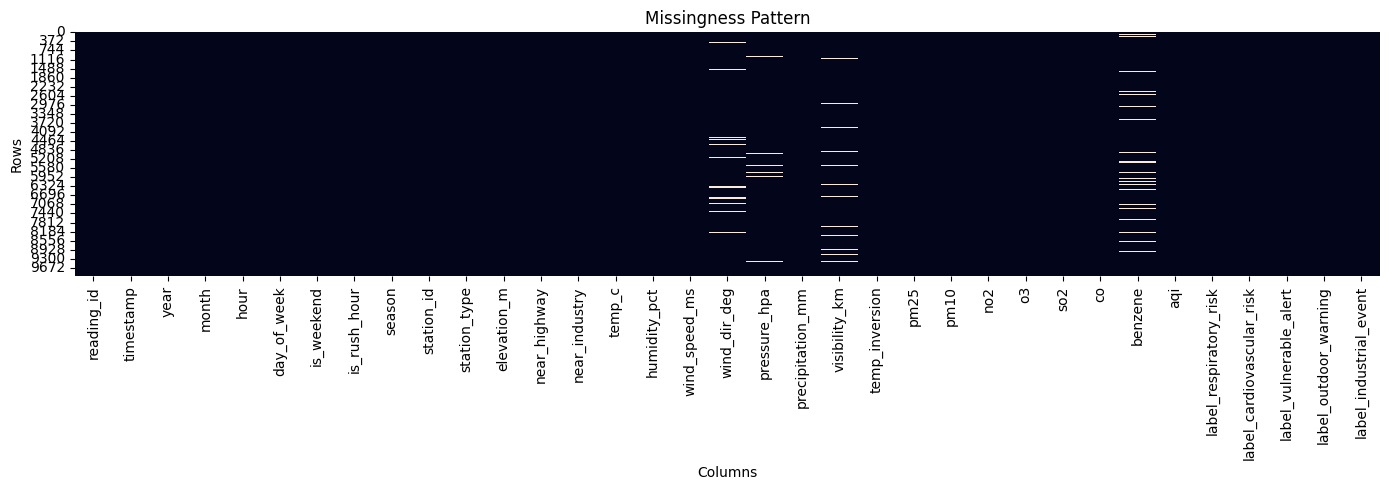

In [33]:
plt.figure(figsize=(14, 5))
sns.heatmap(df.isna(), cbar=False)
plt.title("Missingness Pattern")
plt.xlabel("Columns")
plt.ylabel("Rows")
plt.tight_layout()

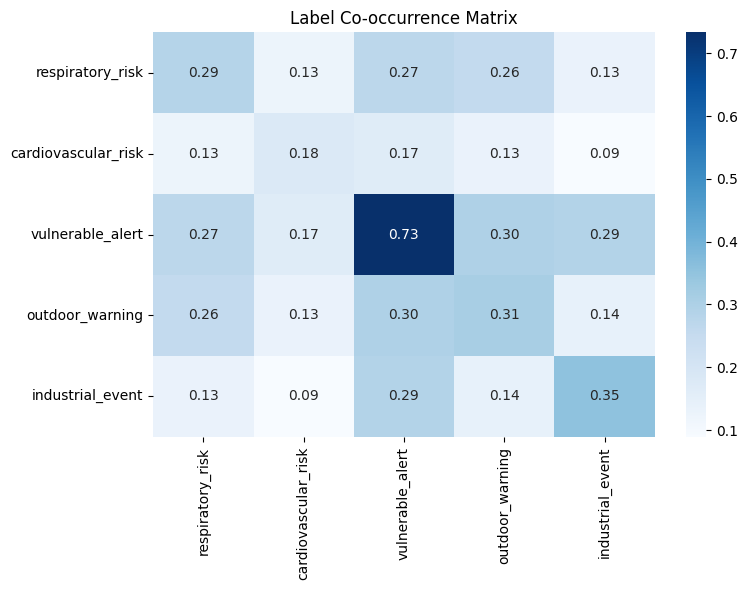

In [36]:
co_occ = df[label_cols].T.dot(df[label_cols])
co_occ_norm = co_occ / len(df)

plt.figure(figsize=(8, 6))
sns.heatmap(
    co_occ_norm,
    annot=True,
    fmt=".2f",
    cmap="Blues",
    xticklabels=[c.replace("label_", "") for c in label_cols],
    yticklabels=[c.replace("label_", "") for c in label_cols],
)
plt.title("Label Co-occurrence Matrix")
plt.tight_layout()
plt.savefig("../figures/label_cooccurrence.png")

In [37]:
cleaning_rules = {
    "season": "Normalize to Winter/Spring/Summer/Fall; map Autumn -> Fall",
    "station_type": "Strip and title-case values",
    "benzene": "Create missing flag; impute by station_type median",
    "visibility_km": "Create missing flag; impute with 1.0",
    "wind_dir_deg": "Create missing flag; impute with 180 before circular encoding",
    "pressure_hpa": "Create missing flag; impute by month median",
    "pm10": "If pm10 < pm25, correct by setting pm10 = pm25 * 1.5",
    "aqi": "Flag large mismatch vs recomputed PM2.5-based AQI",
    "wind_speed_ms": "Flag exact zero values as possible sensor issues",
}

pd.Series(cleaning_rules, name="planned_rule")

season           Normalize to Winter/Spring/Summer/Fall; map Au...
station_type                           Strip and title-case values
benzene          Create missing flag; impute by station_type me...
visibility_km                 Create missing flag; impute with 1.0
wind_dir_deg     Create missing flag; impute with 180 before ci...
pressure_hpa           Create missing flag; impute by month median
pm10             If pm10 < pm25, correct by setting pm10 = pm25...
aqi              Flag large mismatch vs recomputed PM2.5-based AQI
wind_speed_ms     Flag exact zero values as possible sensor issues
Name: planned_rule, dtype: str

In [ ]:
summary = [
    f"Rows: {len(df):,}",
    f"Columns: {df.shape[1]}",
    f"Duplicate rows excluding reading_id: {dup_no_id}",
    f"PM10 < PM2.5 rows: {pm_invalid.sum()}",
    f"AQI mismatch rows: {aqi_discrepancy.sum()}",
    f"Wind speed = 0.0 rows: {stuck_anemometer.sum()}",
]

for line in summary:
    print(line)